# Core Benchmark Analysis

Notebook ini digunakan untuk mempresentasikan dan menganalisis hasil benchmark inti yang dihasilkan oleh pipeline `experiments/scripts/run_core_checkpoint.py`

Notebook ini berfungsi untuk:
- memverifikasi bahwa artefak yang dibaca sesuai dengan run yang dimaksud,
- menyajikan hasil dalam bentuk tabel dan visualisasi yang lebih mudah ditafsirkan,
- mendokumentasikan interpretasi teknikal terhadap performa masing-masing engine.


## Content

Alur analisis pada notebook ini disusun secara berurutan agar konsisten dengan logika evaluasi eksperimental.

1. **Provenance and Experimental Design**: memverifikasi asal artefak, konfigurasi run, dan cakupan benchmark.
2. **Audit Validity**: menilai apakah run dapat diperlakukan sebagai benchmark final yang sahih.
3. **Scenario-Level Feasibility**: membandingkan kemampuan engine menghasilkan solusi feasible pada masing-masing skenario kendala.
4. **Stability Analysis**: menilai konsistensi rekomendasi pada repeated runs.
5. **Runtime vs Feasibility Trade-off**: membaca kompromi antara utilitas solusi dan biaya komputasi.
6. **Action Pattern Analysis**: mengidentifikasi fitur yang paling sering menjadi leverage recourse.
7. **Candidate-Level Spot Checks**: memeriksa kualitas kandidat secara lebih granular dari sisi jarak, sparsity, dan plausibility.
8. **Analyst Notes**: menyediakan kerangka naratif yang dapat langsung diturunkan ke penulisan naskah Tugas Akhir.


In [35]:
from __future__ import annotations

import ast
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
from IPython.display import HTML, Markdown, display

plt.style.use("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

ENGINE_ORDER = ["dice", "ocean", "ft", "nn"]
SCENARIO_ORDER = ["all_mutable", "lifestyle_combo", "bmi_only", "activity_only", "tight_bounds", "no_mutable"]
ENGINE_COLORS = {"dice": "#1f77b4", "ocean": "#ff7f0e", "ft": "#2ca02c", "nn": "#d62728"}

def style_metric_table(frame: pd.DataFrame, percent_cols: list[str] | None = None, precision: int = 3):
    percent_cols = percent_cols or []
    formatters = {col: lambda x: f"{x:.1%}" if pd.notna(x) else "-" for col in percent_cols if col in frame.columns}
    for col in frame.columns:
        if col in formatters:
            continue
        if pd.api.types.is_float_dtype(frame[col]):
            formatters[col] = lambda x, p=precision: f"{x:.{p}f}" if pd.notna(x) else "-"
    return frame.style.format(formatters)

def make_summary_cards(items: list[tuple[str, str, str]]) -> str:
    cards = []
    for title, value, subtitle in items:
        cards.append(
            f"<div style='padding:14px 16px;border:1px solid #d0d7de;border-radius:10px;background:#f8fafc;min-width:180px'>"
            f"<div style='font-size:12px;color:#475569;text-transform:uppercase;letter-spacing:0.04em'>{title}</div>"
            f"<div style='font-size:28px;font-weight:700;color:#0f172a;margin-top:4px'>{value}</div>"
            f"<div style='font-size:12px;color:#64748b;margin-top:4px'>{subtitle}</div>"
            "</div>"
        )
    return "<div style='display:flex;gap:12px;flex-wrap:wrap;margin:10px 0 18px 0'>" + "".join(cards) + "</div>"

def extract_engine_from_source(path_text: str) -> str:
    parts = Path(path_text).parts
    if "baselines" in parts:
        idx = parts.index("baselines")
        if idx + 1 < len(parts):
            return parts[idx + 1]
    return "unknown"


In [36]:
def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Repo root not found from notebook path.")


REPO_ROOT = find_repo_root(Path.cwd())
RESULTS_ROOT = REPO_ROOT / "experiments" / "results"
LATEST_COMPARISON_POINTER = RESULTS_ROOT / "latest" / "comparison.txt"

if not LATEST_COMPARISON_POINTER.exists():
    raise FileNotFoundError(f"Latest comparison pointer not found: {LATEST_COMPARISON_POINTER}")

COMPARISON_ROOT = Path(LATEST_COMPARISON_POINTER.read_text(encoding="utf-8").strip())
CHECKPOINT_REPORT_PATH = COMPARISON_ROOT / "checkpoint_report.md"
COMPARISON_REPORT_PATH = COMPARISON_ROOT / "comparison_report.md"
CHECKPOINT_MANIFEST_PATH = COMPARISON_ROOT / "checkpoint_manifest.json"
COMPARISON_MANIFEST_PATH = COMPARISON_ROOT / "comparison_manifest.json"
AUDIT_REPORT_PATH = COMPARISON_ROOT / "audit_report.json"
COMBINED_DIR = COMPARISON_ROOT / "combined"

SCENARIO_SUMMARY_PATH = COMBINED_DIR / "scenario_summary.csv"
STABILITY_SUMMARY_PATH = COMBINED_DIR / "stability_summary.csv"
CANDIDATES_PATH = COMBINED_DIR / "candidates.csv"
INPUTS_PATH = COMBINED_DIR / "inputs.csv"

comparison_manifest = json.loads(COMPARISON_MANIFEST_PATH.read_text(encoding="utf-8"))
checkpoint_manifest = json.loads(CHECKPOINT_MANIFEST_PATH.read_text(encoding="utf-8"))
audit_report = json.loads(AUDIT_REPORT_PATH.read_text(encoding="utf-8"))

scenario_df = pd.read_csv(SCENARIO_SUMMARY_PATH) if SCENARIO_SUMMARY_PATH.exists() else pd.DataFrame()
stability_df = pd.read_csv(STABILITY_SUMMARY_PATH) if STABILITY_SUMMARY_PATH.exists() else pd.DataFrame()
candidates_df = pd.read_csv(CANDIDATES_PATH) if CANDIDATES_PATH.exists() else pd.DataFrame()
inputs_df = pd.read_csv(INPUTS_PATH) if INPUTS_PATH.exists() else pd.DataFrame()

print(f"Comparison root: {COMPARISON_ROOT}")
print(f"Scenario rows: {len(scenario_df)} | Stability rows: {len(stability_df)} | Candidate rows: {len(candidates_df)}")


Comparison root: D:\Perkuliahan\Tugas Akhir - The Last Chapter\Program\diabetify-cf\experiments\results\comparisons\20260506_065338
Scenario rows: 24 | Stability rows: 4 | Candidate rows: 198


## Executive Summary

Bagian ini merangkum indikator paling penting dari run yang sedang dibaca. Tujuannya adalah memberikan gambaran awal secara cepat mengenai status audit, engine dengan utilitas terbaik, stabilitas terbaik, serta engine tercepat, sebelum pembahasan dilanjutkan ke analisis yang lebih rinci.


In [37]:
scenario_with_engine = scenario_df.assign(engine=scenario_df["source_file"].map(extract_engine_from_source)) if not scenario_df.empty else pd.DataFrame()
stability_with_engine = stability_df.assign(engine=stability_df["source_file"].map(extract_engine_from_source)) if not stability_df.empty else pd.DataFrame()

engine_summary_for_cards = pd.DataFrame()
if not scenario_with_engine.empty:
    engine_summary_for_cards = (
        scenario_with_engine.groupby("engine", as_index=False)
        .agg(
            mean_feasible_rate=("feasible_rate", "mean"),
            mean_runtime_ms=("mean_runtime_ms", "mean"),
            timeout_count=("step_status", lambda s: int((s == "timeout").sum())),
        )
        .sort_values("mean_feasible_rate", ascending=False)
    )

best_engine = engine_summary_for_cards.iloc[0]["engine"] if not engine_summary_for_cards.empty else "-"
best_feasible = engine_summary_for_cards.iloc[0]["mean_feasible_rate"] if not engine_summary_for_cards.empty else float("nan")
fastest_engine = engine_summary_for_cards.sort_values("mean_runtime_ms").iloc[0]["engine"] if not engine_summary_for_cards.empty else "-"
fastest_runtime = engine_summary_for_cards.sort_values("mean_runtime_ms").iloc[0]["mean_runtime_ms"] if not engine_summary_for_cards.empty else float("nan")
best_stability_engine = "-"
best_stability = float("nan")
if not stability_with_engine.empty:
    best_stability_row = stability_with_engine.sort_values(["mean_feasible_rate", "mean_feasible_only_jaccard_changed_features"], ascending=[False, False]).iloc[0]
    best_stability_engine = best_stability_row["engine"]
    best_stability = best_stability_row["mean_feasible_rate"]

cards_html = make_summary_cards([
    ("Checkpoint", "PASS" if audit_report.get("ok") else "FAIL", f"errors={len(audit_report.get("errors", []))}, warnings={len(audit_report.get("warnings", []))}"),
    ("Best Feasibility", f"{best_engine} ({best_feasible:.0%})" if pd.notna(best_feasible) else "-", "mean feasible rate across scenarios"),
    ("Best Stability", f"{best_stability_engine} ({best_stability:.0%})" if pd.notna(best_stability) else "-", "mean feasible rate on repeated runs"),
    ("Fastest Engine", f"{fastest_engine} ({fastest_runtime:.0f} ms)" if pd.notna(fastest_runtime) else "-", "mean runtime across scenarios"),
])
display(HTML(cards_html))

if not engine_summary_for_cards.empty:
    executive_view = engine_summary_for_cards.copy()
    executive_view["mean_feasible_rate"] = executive_view["mean_feasible_rate"].round(3)
    executive_view["mean_runtime_ms"] = executive_view["mean_runtime_ms"].round(1)
    display(style_metric_table(executive_view, percent_cols=["mean_feasible_rate"]))


,engine,mean_feasible_rate,mean_runtime_ms,timeout_count
2,nn,45.0%,202.200,0
0,dice,33.3%,142.400,3
3,ocean,28.3%,2539.100,0
1,ft,25.0%,181.200,0


## 1. Provenance and Experimental Design

Bagian ini memastikan bahwa notebook membaca artefak hasil yang benar dan bahwa konfigurasi eksperimen yang divisualisasikan memang sesuai dengan benchmark inti yang direncanakan. Dalam konteks penelitian, verifikasi provenance ini penting agar seluruh analisis berikutnya dapat ditelusuri kembali ke run yang eksplisit, terdokumentasi, dan dapat diulang.


In [38]:
design_summary = pd.DataFrame(
    [
        {
            "comparison_root": str(COMPARISON_ROOT),
            "engines": ", ".join(comparison_manifest.get("engines", [])),
            "scenario_count": len(comparison_manifest.get("scenario_configs", [])),
            "scenario_limit": comparison_manifest.get("scenario_limit"),
            "stability_limit": comparison_manifest.get("stability_limit"),
            "repeat_count": comparison_manifest.get("repeat_count"),
            "scenario_timeout_seconds": comparison_manifest.get("scenario_timeout_seconds"),
            "stability_timeout_seconds": comparison_manifest.get("stability_timeout_seconds"),
            "checkpoint_ok": checkpoint_manifest.get("ok"),
            "fail_on_timeout": audit_report.get("fail_on_timeout"),
        }
    ]
)
display(design_summary.T.rename(columns={0: "value"}))


,value
comparison_root,D:\Perkuliahan\Tugas Akhir - The Last Chapter\Program\diabetify-cf\experiments\results\comparisons\20260506_065338
engines,"dice, ocean, ft, nn"
scenario_count,6
scenario_limit,10
stability_limit,10
repeat_count,5
scenario_timeout_seconds,180
stability_timeout_seconds,180
checkpoint_ok,False
fail_on_timeout,True


**Interpretation.** Tabel provenance menunjukkan bahwa run ini menggunakan cakupan benchmark inti yang konsisten, yaitu `dice`, `ocean`, `ft`, dan `nn`, yang dievaluasi pada `6` skenario dengan `scenario_limit=10`, `stability_limit=10`, dan `repeat_count=5`.

Dua atribut yang paling menentukan dalam konteks validitas evaluasi adalah `checkpoint_ok` dan `fail_on_timeout`. Nilai `fail_on_timeout=True` menegaskan bahwa benchmark final memang dijalankan dalam mode audit ketat, sehingga timeout pada skenario inti diklasifikasikan sebagai kegagalan evaluasi, bukan sekadar peringatan operasional.

Dengan demikian, bagian ini berfungsi sebagai landasan metodologis bahwa seluruh hasil yang ditampilkan pada section berikutnya benar-benar berasal dari desain eksperimen yang telah dikunci sebelumnya.


## 2. Audit Validity

Validitas run harus selalu dibaca **sebelum** performa engine ditafsirkan. Pada penelitian yang berorientasi evaluasi komparatif, hasil yang secara numerik terlihat baik tetap tidak dapat diperlakukan sebagai evidence final apabila cakupan run tidak lengkap atau audit menunjukkan kegagalan.


In [39]:
audit_overview = pd.DataFrame(
    [
        {
            "checkpoint_status": "PASS" if audit_report.get("ok") else "FAIL",
            "observed_engines": ", ".join(audit_report.get("observed_engines", [])),
            "scenario_rows": audit_report.get("row_counts", {}).get("scenario"),
            "stability_rows": audit_report.get("row_counts", {}).get("stability"),
            "candidate_rows": audit_report.get("row_counts", {}).get("candidates"),
            "error_count": len(audit_report.get("errors", [])),
            "warning_count": len(audit_report.get("warnings", [])),
        }
    ]
)
display(audit_overview.T.rename(columns={0: "value"}))

if audit_report.get("errors"):
    display(Markdown("**Audit errors**"))
    for item in audit_report["errors"]:
        display(Markdown(f"- {item}"))

if audit_report.get("warnings"):
    display(Markdown("**Audit warnings**"))
    for item in audit_report["warnings"]:
        display(Markdown(f"- {item}"))


,value
checkpoint_status,FAIL
observed_engines,"dice, ft, nn, ocean"
scenario_rows,24
stability_rows,4
candidate_rows,198
error_count,3
warning_count,0


**Audit errors**

- dice/bmi_only timed out.

- dice/activity_only timed out.

- dice/tight_bounds timed out.

**Interpretation.** Status `FAIL` pada run ini disebabkan oleh `3` timeout milik `dice`, masing-masing pada skenario `bmi_only`, `activity_only`, dan `tight_bounds`. Tidak terdapat warning tambahan, sehingga sumber kegagalan bersifat terlokalisasi pada kombinasi engine-skenario tertentu, bukan pada pipeline secara keseluruhan.

Secara praktis, hal ini berarti artefak hasil masih layak digunakan untuk analisis eksploratif, khususnya untuk membaca pola feasibility, stability, runtime, dan action pattern. Namun, run ini belum dapat diposisikan sebagai benchmark final yang sepenuhnya sahih karena tidak seluruh cakupan evaluasi inti terselesaikan sesuai kebijakan audit.

Dalam penulisan akademik, distinction ini penting: run dapat tetap informatif untuk pembahasan teknikal, tetapi klaim komparatif final sebaiknya hanya didasarkan pada run yang lolos audit secara penuh.


## 3. Scenario-Level Feasibility

Section ini membandingkan kemampuan setiap engine untuk menghasilkan solusi counterfactual yang feasible pada masing-masing skenario kendala. Ringkasan pada `scenario_summary.csv` menggunakan **top-ranked candidate per request** sebagai basis agregasi utama, sehingga interpretasi antar engine menjadi lebih adil meskipun jumlah kandidat mentah yang dihasilkan masing-masing engine berbeda.


,engine,scenario,step_status,feasible_rate,target_success_rate,mean_runtime_ms,reason_counts,requests_with_candidates
0,dice,all_mutable,completed,100.0%,100.0%,435.500,"{""OK"": 10}",10.000
18,ocean,all_mutable,completed,60.0%,100.0%,3257.600,"{""OK"": 6, ""MEDICAL_RULE_VIOLATION_ONLY"": 2, ""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 2}",6.000
6,ft,all_mutable,completed,40.0%,100.0%,86.200,"{""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 6, ""OK"": 4}",4.000
12,nn,all_mutable,completed,100.0%,100.0%,491.200,"{""OK"": 10}",10.000
1,dice,lifestyle_combo,completed,100.0%,100.0%,414.800,"{""OK"": 10}",10.000
19,ocean,lifestyle_combo,completed,80.0%,100.0%,3138.700,"{""OK"": 8, ""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 2}",8.000
7,ft,lifestyle_combo,completed,40.0%,100.0%,82.200,"{""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 6, ""OK"": 4}",4.000
13,nn,lifestyle_combo,completed,100.0%,100.0%,358.700,"{""OK"": 10}",10.000
2,dice,bmi_only,timeout,0.0%,0.0%,0.000,"{""timeout"": 1}",-
20,ocean,bmi_only,completed,30.0%,100.0%,3100.500,"{""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 7, ""OK"": 3}",3.000


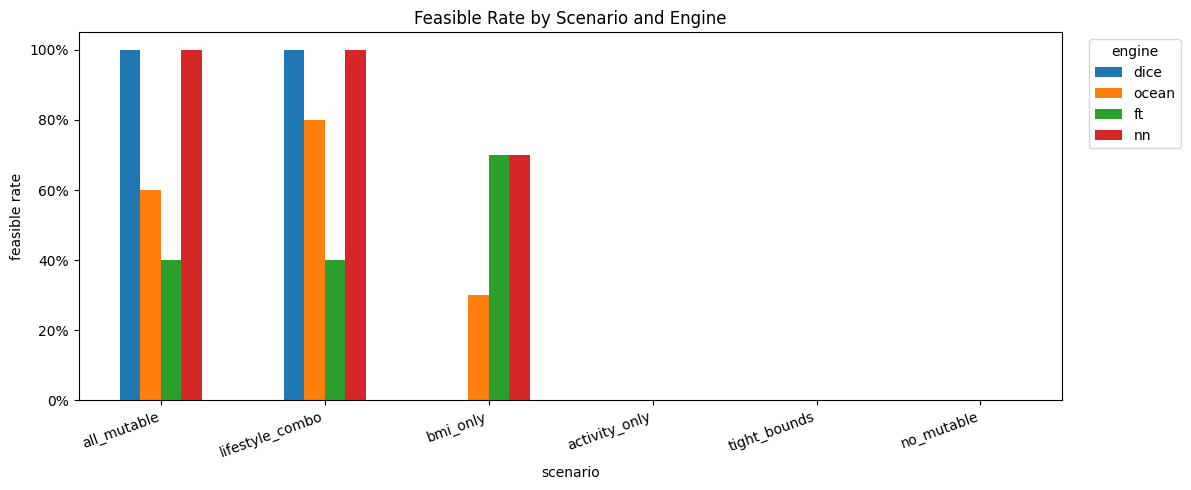

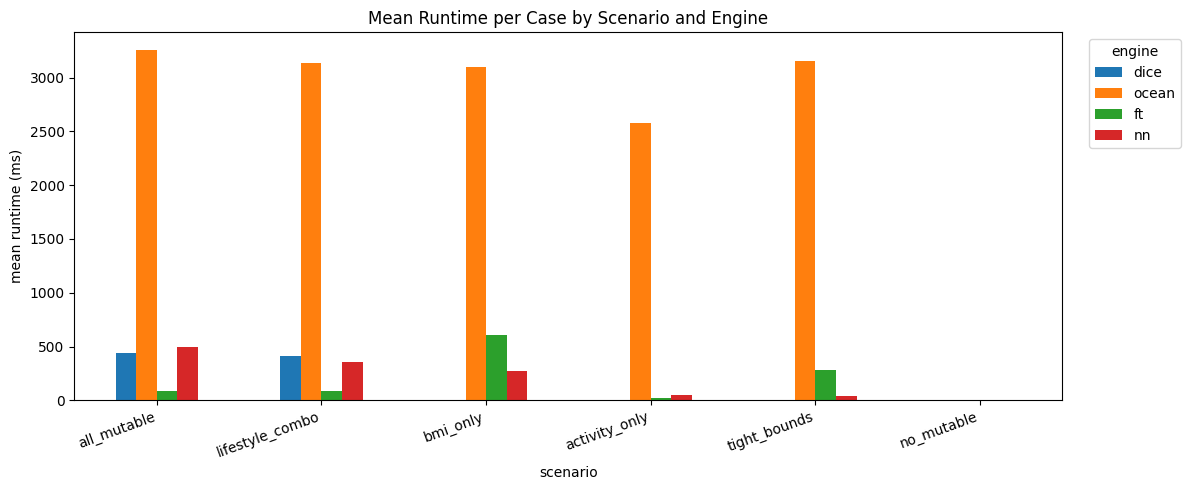

In [40]:
scenario_view = scenario_df.copy()
if not scenario_view.empty:
    scenario_view["engine"] = pd.Categorical(scenario_view["source_file"].map(extract_engine_from_source), categories=ENGINE_ORDER, ordered=True)
    scenario_view["scenario"] = pd.Categorical(scenario_view["scenario"], categories=SCENARIO_ORDER, ordered=True)
    scenario_view = scenario_view[["engine", "scenario", "step_status", "feasible_rate", "target_success_rate", "mean_runtime_ms", "reason_counts", "requests_with_candidates"]].sort_values(["scenario", "engine"])
    display(style_metric_table(scenario_view, percent_cols=["feasible_rate", "target_success_rate"]))
    heatmap_df = scenario_view.pivot(index="engine", columns="scenario", values="feasible_rate").reindex(index=ENGINE_ORDER, columns=SCENARIO_ORDER)
    ax = heatmap_df.T.plot(kind="bar", figsize=(12, 5), color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in heatmap_df.index])
    ax.set_title("Feasible Rate by Scenario and Engine")
    ax.set_ylabel("feasible rate")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(title="engine", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
    runtime_pivot = scenario_view.pivot(index="engine", columns="scenario", values="mean_runtime_ms").reindex(index=ENGINE_ORDER, columns=SCENARIO_ORDER)
    ax = runtime_pivot.T.plot(kind="bar", figsize=(12, 5), color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in runtime_pivot.index])
    ax.set_title("Mean Runtime per Case by Scenario and Engine")
    ax.set_ylabel("mean runtime (ms)")
    ax.legend(title="engine", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


**Interpretation.** Hasil pada level skenario menunjukkan pola performa yang cukup terstruktur.

- `nn` tampak sebagai engine dengan keseimbangan terbaik pada run ini, karena mampu mempertahankan feasibility tinggi pada skenario longgar dan masih memberikan performa kuat pada `bmi_only`.
- `dice` menunjukkan performa sangat baik pada skenario yang relatif longgar, khususnya `all_mutable` dan `lifestyle_combo`, tetapi robustnes-nya terhadap kendala yang lebih sempit belum memadai karena tiga skenario berakhir timeout.
- `ft` secara umum lebih lemah dari sisi feasibility agregat, walaupun tetap menunjukkan daya guna pada `bmi_only`.
- `ocean` masih relevan sebagai pembanding karena mampu menghasilkan solusi pada beberapa skenario penting, tetapi beban komputasinya jauh lebih tinggi dibanding engine lain.

Dari perspektif desain eksperimen, `activity_only`, `tight_bounds`, dan `no_mutable` berfungsi sebagai skenario stres. Dua yang pertama mengindikasikan bahwa ruang solusi menjadi sangat sempit ketika tindakan dibatasi secara agresif, sedangkan `no_mutable` berperan baik sebagai kontrol negatif karena memang tidak memberi ruang perubahan yang dapat diaksi oleh engine.


## 4. Stability Analysis

Stability analysis mengevaluasi apakah engine menghasilkan rekomendasi yang konsisten ketika proses pencarian diulang pada kasus yang sama. Dalam konteks tree-ensemble counterfactuals, dimensi ini penting karena salah satu masalah utama yang ingin diatasi adalah ketidakstabilan solusi akibat ruang keputusan yang diskrit dan tidak mulus.


,engine,case_count,mean_feasible_rate,fully_feasible_case_rate,stability_evaluable_case_rate,mean_jaccard_changed_features,mean_feasible_only_jaccard_changed_features,mean_feasible_only_stability_std_norm
0,dice,10,100.0%,100.0%,100.0%,0.983,0.983,0.019
3,ocean,10,72.0%,60.0%,80.0%,0.900,1.000,0.000
1,ft,10,40.0%,40.0%,40.0%,1.000,1.000,0.000
2,nn,10,100.0%,100.0%,100.0%,1.000,1.000,0.000


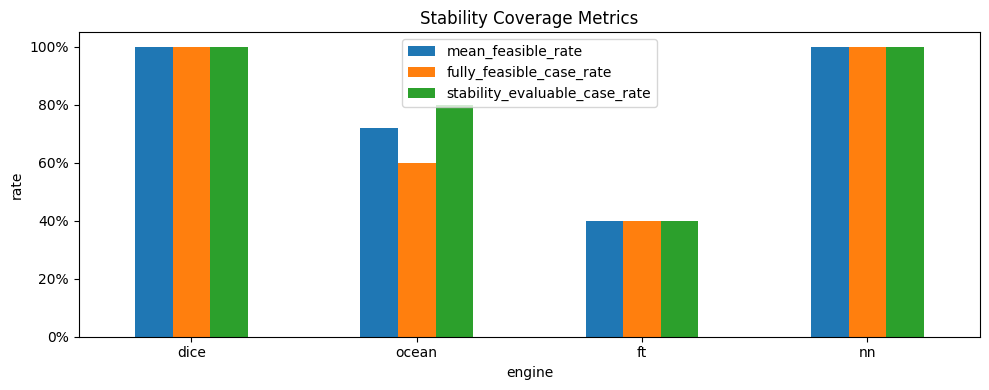

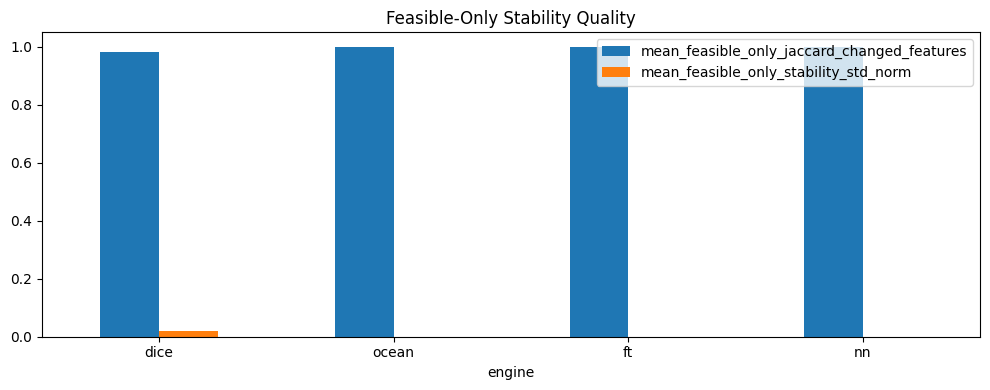

In [41]:
stability_view = stability_df.copy()
if not stability_view.empty:
    stability_view["engine"] = pd.Categorical(stability_view["source_file"].map(extract_engine_from_source), categories=ENGINE_ORDER, ordered=True)
    stability_view = stability_view[["engine", "case_count", "mean_feasible_rate", "fully_feasible_case_rate", "stability_evaluable_case_rate", "mean_jaccard_changed_features", "mean_feasible_only_jaccard_changed_features", "mean_feasible_only_stability_std_norm"]].sort_values("engine")
    display(style_metric_table(stability_view, percent_cols=["mean_feasible_rate", "fully_feasible_case_rate", "stability_evaluable_case_rate"]))

    plot_cols = ["mean_feasible_rate", "fully_feasible_case_rate", "stability_evaluable_case_rate"]
    ax = stability_view.set_index("engine")[plot_cols].plot(kind="bar", figsize=(10, 4), rot=0, color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in stability_view["engine"].astype(str)])
    ax.set_title("Stability Coverage Metrics")
    ax.set_ylabel("rate")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.tight_layout()
    plt.show()

    ax = stability_view.set_index("engine")[["mean_feasible_only_jaccard_changed_features", "mean_feasible_only_stability_std_norm"]].plot(kind="bar", figsize=(10, 4), rot=0, color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in stability_view["engine"].astype(str)])
    ax.set_title("Feasible-Only Stability Quality")
    plt.tight_layout()
    plt.show()


**Interpretation.** Hasil stability harus dibaca bersamaan dengan coverage feasibility. `dice` dan `nn` menunjukkan `mean_feasible_rate=1.00` pada subset stability yang diuji, disertai `Jaccard` yang sangat tinggi. Ini mengindikasikan bahwa ketika solusi berhasil ditemukan, pola perubahan fitur yang dihasilkan cenderung konsisten antar repeated runs.

`ocean` tetap menunjukkan kualitas stabilitas yang baik pada case yang feasible, namun coverage-nya lebih rendah. Dengan kata lain, konsistensi internalnya cukup baik, tetapi tidak berlaku pada seluruh kasus yang diuji. `ft` tampak sangat stabil pada feasible-only view, namun interpretasi ini harus dibatasi karena subset case feasible-nya jauh lebih kecil.

Secara metodologis, kesimpulan yang lebih defensible adalah bahwa stabilitas tidak boleh dipisahkan dari availability of feasible solutions. Engine yang sangat stabil pada sedikit kasus tidak otomatis lebih unggul daripada engine yang sedikit kurang stabil tetapi jauh lebih sering menghasilkan solusi feasible.


## 5. Runtime vs Feasibility Trade-off

Bagian ini mengevaluasi kompromi antara utilitas praktis dan biaya komputasi. Untuk konteks implementasi sistem nyata, engine yang menghasilkan solusi baik tetapi sangat mahal secara runtime belum tentu menjadi pilihan terbaik apabila alternatif lain memberi kualitas serupa dengan biaya yang lebih rendah.


,engine,mean_feasible_rate,mean_runtime_ms,timeout_count
0,dice,33.3%,142.400,3
3,ocean,28.3%,2539.083,0
1,ft,25.0%,181.167,0
2,nn,45.0%,202.167,0


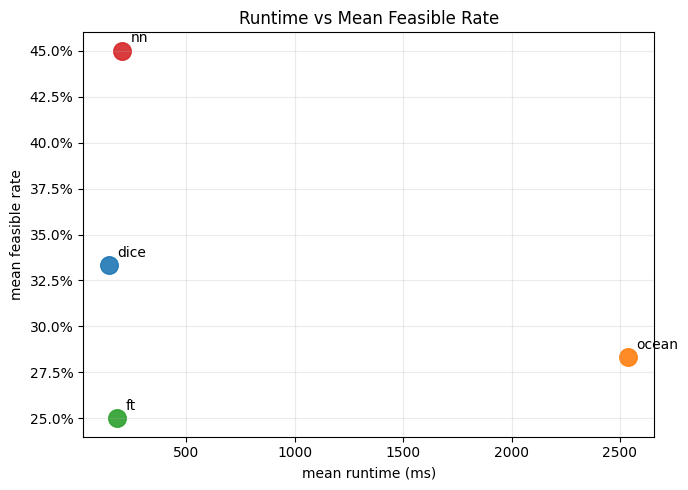

In [42]:
if not scenario_df.empty:
    engine_summary = (
        scenario_df.assign(engine=scenario_df["source_file"].map(extract_engine_from_source))
        .groupby("engine", as_index=False)
        .agg(
            mean_feasible_rate=("feasible_rate", "mean"),
            mean_runtime_ms=("mean_runtime_ms", "mean"),
            timeout_count=("step_status", lambda s: int((s == "timeout").sum())),
        )
    )
    engine_summary["engine"] = pd.Categorical(engine_summary["engine"], categories=ENGINE_ORDER, ordered=True)
    engine_summary = engine_summary.sort_values("engine")
    display(style_metric_table(engine_summary, percent_cols=["mean_feasible_rate"]))

    fig, ax = plt.subplots(figsize=(7, 5))
    for _, row in engine_summary.iterrows():
        engine_name = str(row["engine"])
        ax.scatter(row["mean_runtime_ms"], row["mean_feasible_rate"], s=160, color=ENGINE_COLORS.get(engine_name, "#4b5563"), alpha=0.9)
        ax.annotate(engine_name, (row["mean_runtime_ms"], row["mean_feasible_rate"]), textcoords="offset points", xytext=(6, 6))
    ax.set_title("Runtime vs Mean Feasible Rate")
    ax.set_xlabel("mean runtime (ms)")
    ax.set_ylabel("mean feasible rate")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


**Interpretation.** Scatter plot runtime versus feasibility memperjelas trade-off antar engine.

- `nn` menempati posisi paling menarik karena memiliki mean feasible rate tertinggi dengan runtime yang masih moderat.
- `ocean` cenderung berada pada wilayah biaya komputasi tinggi, sementara peningkatan feasibility yang diberikannya tidak dominan dibanding alternatif lain.
- `dice` tampak relatif cepat pada skenario yang selesai dieksekusi, tetapi interpretasi ini harus diberi catatan karena adanya `3` timeout yang membuat evaluasinya tidak lengkap.
- `ft` relatif ringan secara komputasi, namun utilitas agregatnya masih lebih rendah.

Dari sudut pandang rekayasa sistem, visualisasi ini membantu membedakan engine yang sekadar feasible dari engine yang benar-benar efisien untuk digunakan pada pipeline rekomendasi yang lebih operasional.


## 6. Action Pattern Analysis

Action pattern analysis digunakan untuk membaca fitur mana yang paling sering menjadi titik intervensi pada solusi counterfactual. Informasi ini penting karena memberikan indikasi mengenai leverage model, sekaligus membantu menghubungkan hasil komputasional dengan interpretasi domain medis dan aksiabilitas pengguna.


,engine,feature,count
0,dice,BMI,57
1,dice,smoking_status,24
2,dice,brinkman_index,13
3,dice,is_hypertension,6
4,dice,moderate_physical_activity_frequency,2
5,ft,BMI,38
6,ft,is_hypertension,12
7,ft,smoking_status,7
8,ft,brinkman_index,5
9,nn,BMI,76


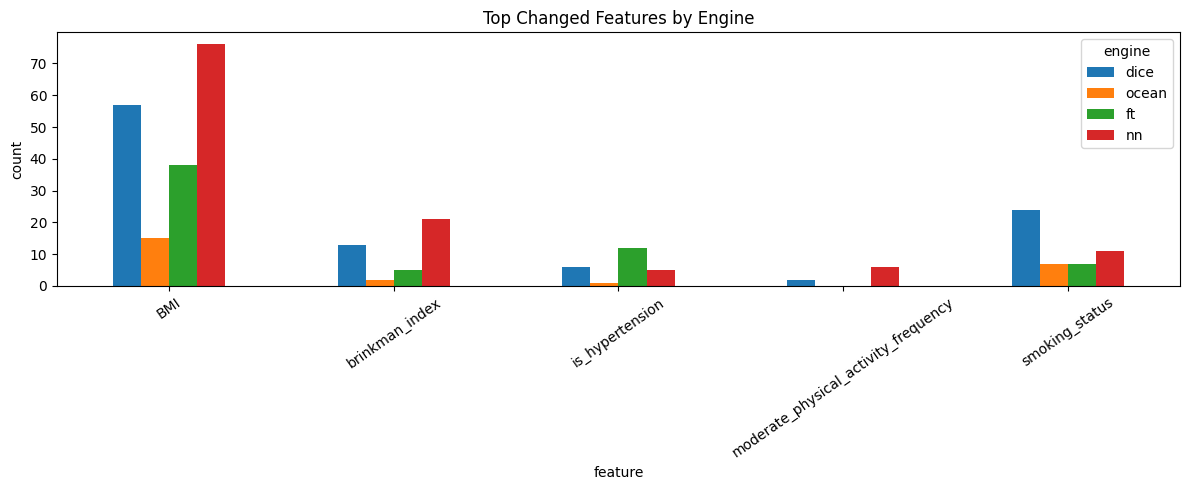

In [43]:
def top_changed_features(frame: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    if frame.empty or "delta" not in frame.columns:
        return pd.DataFrame()
    for _, row in frame.iterrows():
        try:
            delta = ast.literal_eval(row["delta"])
        except Exception:
            continue
        if not isinstance(delta, dict):
            continue
        for feature_name in delta:
            rows.append({"engine": row["engine_name"], "feature": str(feature_name)})
    if not rows:
        return pd.DataFrame()
    out = (
        pd.DataFrame(rows)
        .value_counts(["engine", "feature"])
        .rename("count")
        .reset_index()
        .sort_values(["engine", "count"], ascending=[True, False])
    )
    return out

feature_counts = top_changed_features(candidates_df)
display(feature_counts.groupby("engine").head(5).reset_index(drop=True) if not feature_counts.empty else feature_counts)

if not feature_counts.empty:
    top_feature_pivot = (
        feature_counts.groupby("engine").head(5)
        .pivot(index="feature", columns="engine", values="count")
        .reindex(columns=ENGINE_ORDER)
        .fillna(0)
    )
    ax = top_feature_pivot.plot(kind="bar", figsize=(12, 5), rot=35, color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in top_feature_pivot.columns])
    ax.set_title("Top Changed Features by Engine")
    ax.set_ylabel("count")
    plt.tight_layout()
    plt.show()


**Interpretation.** `BMI` muncul sebagai fitur yang paling sering diubah pada hampir seluruh engine, dengan frekuensi yang secara jelas melampaui fitur lain. Di bawahnya, pola perubahan paling sering jatuh pada `smoking_status`, `brinkman_index`, serta dalam frekuensi yang lebih kecil `is_hypertension` dan `moderate_physical_activity_frequency`.

Secara substantif, temuan ini menunjukkan bahwa model XGBoost yang digunakan tampaknya paling sensitif terhadap faktor antropometrik dan indikator perilaku merokok. Aktivitas fisik memang muncul sebagai komponen recourse, tetapi bukan sebagai leverage dominan pada mayoritas solusi terbaik.

Temuan ini relevan bagi rancangan counterfactual planner final, karena ia memberi sinyal bahwa rekomendasi yang paling efektif kemungkinan besar akan berputar pada sejumlah kecil fitur kunci, bukan tersebar merata pada seluruh fitur mutable.


## 7. Candidate-Level Spot Checks

Section ini menyajikan inspeksi granular terhadap kandidat solusi. Fokusnya bukan lagi pada agregasi antarskenario, melainkan pada karakter solusi itu sendiri: seberapa besar perubahan yang diminta, seberapa sparse solusi tersebut, dan seberapa plausible posisinya relatif terhadap distribusi data referensi.


,engine_name,request_id,candidate_id,probability_low_risk,distance_l1,changed_feature_count,lof_score,delta
2,dice,exp-00001,cf_3,0.5823,0.1611,3,1.0291,"{""brinkman_index"": -1.0, ""BMI"": -5.810535, ""smoking_status"": -2.0}"
31,dice,exp-00001,cf_3,0.5823,0.1611,3,1.0291,"{""smoking_status"": -2.0, ""BMI"": -5.810535, ""brinkman_index"": -1.0}"
0,dice,exp-00001,cf_1,0.5793,0.1295,2,1.0194,"{""BMI"": -8.28335, ""is_hypertension"": -1.0}"
29,dice,exp-00001,cf_1,0.5793,0.1295,2,1.0194,"{""is_hypertension"": -1.0, ""BMI"": -8.28335}"
1,dice,exp-00001,cf_2,0.5290,0.1601,3,1.0383,"{""brinkman_index"": -1.0, ""BMI"": -5.400015, ""smoking_status"": -2.0}"
30,dice,exp-00001,cf_2,0.5290,0.1601,3,1.0383,"{""smoking_status"": -2.0, ""BMI"": -5.400015, ""brinkman_index"": -1.0}"
34,dice,exp-00002,cf_3,0.5452,0.0052,1,0.9926,"{""BMI"": -2.328124}"
5,dice,exp-00002,cf_3,0.5204,0.0046,1,0.9884,"{""BMI"": -2.053083}"
4,dice,exp-00002,cf_2,0.5029,0.0037,1,0.9856,"{""BMI"": -1.681016}"
33,dice,exp-00002,cf_2,0.5029,0.0037,1,0.9856,"{""BMI"": -1.681016}"


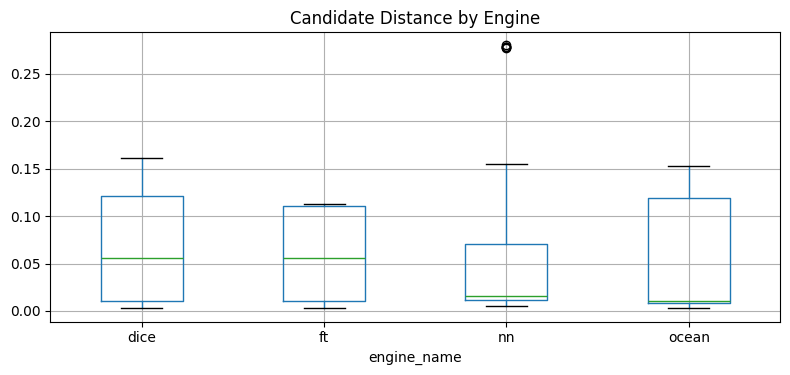

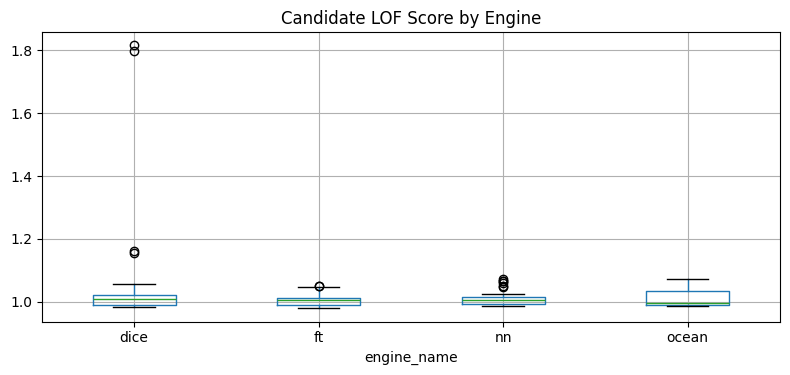

In [44]:
if not candidates_df.empty:
    candidate_view = candidates_df[["engine_name", "request_id", "candidate_id", "probability_low_risk", "distance_l1", "changed_feature_count", "lof_score", "delta"]].copy()
    candidate_view = candidate_view.sort_values(["engine_name", "request_id", "probability_low_risk"], ascending=[True, True, False])
    display(style_metric_table(candidate_view.head(16), precision=4))

    ax = candidate_view.boxplot(column="distance_l1", by="engine_name", figsize=(8, 4), rot=0)
    plt.suptitle("")
    plt.title("Candidate Distance by Engine")
    plt.tight_layout()
    plt.show()

    ax = candidate_view.boxplot(column="lof_score", by="engine_name", figsize=(8, 4), rot=0)
    plt.suptitle("")
    plt.title("Candidate LOF Score by Engine")
    plt.tight_layout()
    plt.show()


**Interpretation.** Sampel kandidat yang ditampilkan konsisten dengan hasil action pattern analysis: banyak solusi terbaik dapat dicapai melalui perubahan yang relatif kecil pada `BMI`, kadang dikombinasikan dengan `smoking_status` atau `brinkman_index`.

Boxplot `distance_l1` memberikan gambaran mengenai magnitudo perubahan yang disarankan engine, sedangkan boxplot `lof_score` memberi indikasi plausibility relatif terhadap distribusi referensi. Dalam pembahasan akademik, section ini berguna sebagai bukti kualitatif bahwa solusi yang dihasilkan tidak hanya feasible, tetapi juga cenderung sparse dan masih berada pada wilayah data yang wajar secara statistik.

Section ini juga membantu menjembatani hasil agregat dengan contoh konkret, sehingga argumen mengenai kualitas solusi tidak berhenti pada angka ringkasan semata.


## 8. Analyst Notes

Bagian ini dapat digunakan untuk menulis narasi akhir setelah seluruh tabel dan visualisasi dibaca. Dalam praktik penulisan Tugas Akhir, poin-poin berikut biasanya cukup untuk menyusun kerangka pembahasan hasil.

Template interpretasi untuk run yang sedang dibaca:
- **Validitas eksperimental**: checkpoint gagal karena `dice` timeout pada `bmi_only`, `activity_only`, dan `tight_bounds`, sehingga run ini informatif tetapi belum final.
- **Performa komparatif**: `nn` tampak paling seimbang antara feasibility dan stability pada run ini.
- **Trade-off komputasi**: `ocean` tetap bernilai sebagai pembanding, tetapi biaya runtime-nya jauh lebih tinggi.
- **Kepatuhan constraint**: seluruh engine yang lolos tetap mempertahankan violation rate `0.0`, yang mendukung validitas mekanisme constraint pada pipeline evaluasi.
- **Makna skenario restriktif**: kegagalan luas pada `activity_only` dan `tight_bounds` mendukung hipotesis bahwa ruang solusi menjadi sangat terbatas ketika aksi pengguna dibatasi terlalu sempit.
- **Makna pola tindakan**: dominasi `BMI` menunjukkan bahwa model banyak meletakkan leverage keputusan pada fitur antropometrik tersebut.

Untuk naskah formal, penutupan analisis sebaiknya disusun dalam tiga lapis argumen:
1. **validitas eksperimental**, yaitu apakah run dapat diperlakukan sebagai evidence final;
2. **perbandingan performa engine**, yaitu siapa yang paling feasible, stabil, dan efisien;
3. **implikasi terhadap rancangan counterfactual planner**, yaitu insight apa yang dapat dibawa ke desain modul akhir yang lebih robust, actionable, dan plausible.
